
## REINFORCE, Advantage Actor-Critic (A2C), and A3C
### Continuous Mountain Car







### Notations

- $S_t$: state at time $t$
- $A_t$: action sampled at time $t$
- $R_{t+1}$: reward after taking $A_t$
- $G_t=\sum_{k=0}^{T-t-1}\gamma^kR_{t+k+1}$: return-to-go
- $\pi_\theta(a\mid s)$: differentiable stochastic policy with parameters $\theta$
- $J(\theta)$: expected-return objective
- $\hat V_w(s)$: learned state-value function with parameters $w$
- $A^\pi(s,a)=q^\pi(s,a)-V^\pi(s)$: advantage
- $\delta_t$: one-step TD error
- $\alpha_a,\alpha_c$: actor and critic learning rates


## 0. Setup

This cell installs missing packages only. A managed laboratory installation should already contain them.

In [7]:
import importlib.util
import os
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

required = {
    "gymnasium": "gymnasium[classic-control]>=1.0,<2.0",
    "numpy": "numpy>=1.24",
    "matplotlib": "matplotlib>=3.7",
    "torch": "torch>=2.2",
}
missing = [
    package
    for module, package in required.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing]
    )
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [8]:
import random
from dataclasses import dataclass

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Normal

SEED = 7
DEVICE = torch.device("cpu")

# Map the two Mountain Car state coordinates to comparable numerical scales.
STATE_CENTER = torch.tensor([-0.3, 0.0], dtype=torch.float32, device=DEVICE)
STATE_SCALE = torch.tensor([0.9, 0.07], dtype=torch.float32, device=DEVICE)


MOMENTUM_REWARD_SCALE = 20.0


def set_global_seed(seed):
    '''Seed Python, NumPy, and PyTorch.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def normalise_mountaincar_states(states):
    '''Approximately map position and velocity to [-1, 1].'''
    return (states - STATE_CENTER) / STATE_SCALE


set_global_seed(SEED)
torch.set_num_threads(1)
np.set_printoptions(precision=3, suppress=True)

print("Python version    :", sys.version.split()[0])
print("Gymnasium version :", gym.__version__)
print("NumPy version     :", np.__version__)
print("PyTorch version   :", torch.__version__)
print("Device            :", DEVICE)
print("Random seed       :", SEED)

Python version    : 3.12.13
Gymnasium version : 1.3.0
NumPy version     : 2.0.2
PyTorch version   : 2.11.0+cpu
Device            : cpu
Random seed       : 7


# Part I - Policy-gradient foundation ( This is a small refresher, please refer to Slides shared in class for deeper dive )

## 1. Learn the policy directly

A value-based agent first learns $q(s,a)$ and then chooses


$$a^*(s)=\arg\max_a q(s,a)$$


A policy-gradient agent instead represents the policy directly. For a continuous action, the policy is a probability **density**. A common choice is a Gaussian:

$$\pi_\theta(a\mid s) = \mathscr{N}\left(a; \mu_\theta(s), \sigma_\theta^2(s)\right)$$

The policy parameters determine:

- $\mu_\theta(s)$: the preferred action in state $s$;
- $\sigma_\theta(s)>0$: the exploration spread around that preference.

An action is sampled during training:

$$
\tilde A_t\sim\pi_\theta(\cdot\mid S_t).
$$

The Mountain Car force must lie in $[-1,1]$, so

$$
A_t=\operatorname{clip}(\tilde A_t,-1,1).
$$

The implementation below uses a state-dependent mean and a learned global standard deviation. This is a restricted Gaussian policy: $\sigma_\theta$ is learned but shared across states.

In [9]:
# A small Gaussian-policy example.
example_mean = torch.tensor([2.0])
example_std = torch.tensor([0.60])
example_policy = Normal(example_mean, example_std)
example_raw_action = example_policy.sample()
example_action = example_raw_action.clamp(-1.0, 1.0)

print("Mean force mu          :", example_mean.item())
print("Standard deviation     :", round(example_std.item(), 2))
print("Sampled raw force      :", round(example_raw_action.item(), 3))
print("Force sent to env      :", round(example_action.item(), 3))
print("Log probability        :",
      round(example_policy.log_prob(example_raw_action).item(), 3))

Mean force mu          : 2.0
Standard deviation     : 0.6
Sampled raw force      : 1.912
Force sent to env      : 1.0
Log probability        : -0.419


## 2. Objective and the log-derivative idea

For an episodic task, let a complete trajectory be

$$
\tau=(S_0,A_0,R_1,\ldots,S_T).
$$

The objective is the expected trajectory return:

$$
J(\theta)=\mathbb E_{\tau\sim\pi_\theta}[G(\tau)].
$$

Using the likelihood-ratio identity,

$$
\nabla_\theta p_\theta(\tau)
=p_\theta(\tau)\nabla_\theta\log p_\theta(\tau),
$$

we obtain

$$
\nabla_\theta J(\theta)
=
\mathbb E_{\tau\sim\pi_\theta}
\left[
G(\tau)\nabla_\theta\log p_\theta(\tau)
\right].
$$

The environment transition probabilities do not depend on $\theta$. Therefore,

$$
\nabla_\theta\log p_\theta(\tau)
=
\sum_{t=0}^{T-1}
\nabla_\theta\log\pi_\theta(A_t\mid S_t).
$$

We differentiate the policy, **not the environment**.

## 3. From the policy-gradient theorem to a sampled update

An action at time $t$ cannot change rewards received before time $t$. The complete trajectory return can therefore be replaced by return-to-go:

$$
\nabla_\theta J(\theta)
=
\mathbb E_{\pi_\theta}
\left[
\sum_{t=0}^{T-1}
\gamma^tG_t
\nabla_\theta\log\pi_\theta(A_t\mid S_t)
\right].
$$

Equivalently, the policy-gradient theorem contains the action value:

$$
\nabla_\theta J(\theta)
\propto
\mathbb E_{\substack{S\sim d^{\pi_\theta}\\A\sim\pi_\theta}}
\left[
q^{\pi_\theta}(S,A)
\nabla_\theta\log\pi_\theta(A\mid S)
\right].
$$

REINFORCE uses the Monte Carlo estimate

$$
q^{\pi_\theta}(S_t,A_t)\approx G_t.
$$

Hence one sampled gradient contribution is

$$
\widehat{\nabla_\theta J(\theta)}
=
\gamma^tG_t\nabla_\theta\log\pi_\theta(A_t\mid S_t).
$$

- If $\gamma^tG_t>0$, gradient ascent makes the sampled action more likely.
- If $\gamma^tG_t<0$, gradient ascent makes it less likely.

### Gradient ascent in mathematics, negative loss in PyTorch

Gradient **ascent**:

$$
\theta
\leftarrow
\theta+\alpha\gamma^tG_t
\nabla_\theta\log\pi_\theta(A_t\mid S_t).
$$

PyTorch optimizers minimize a loss. We therefore minimize its negative:

$$
\mathbb L_{\text{policy}}
=
-\sum_{t=0}^{T-1}
\gamma^tG_t\log\pi_\theta(A_t\mid S_t).
$$

Minimizing this loss produces the same parameter direction as maximizing $J(\theta)$.

# Part II - REINFORCE

## 4. Mathematical algorithm first

**Input:** differentiable policy $\pi_\theta(a\mid s)$, learning rate $\alpha>0$, and discount factor $\gamma$.

For each episode:

1. Generate a complete episode using the current policy $\pi_\theta$.
2. For every time $t=0,\ldots,T-1$:
   1. compute return-to-go $G_t$;
   2. form $\gamma^tG_t\nabla_\theta\log\pi_\theta(A_t\mid S_t)$.
3. Sum the contributions and update $\theta$ by gradient ascent.

This is **Monte Carlo policy-gradient learning**: the update waits until the episode is complete and does not learn a separate value function.

## 5. Return-to-go: one numerical example

Suppose

$$
(R_1,R_2,R_3)=(1,0,2),\qquad \gamma=0.9.
$$

Moving backward:

$$
\begin{aligned}
G_2 &= 2,\\
G_1 &= 0+0.9(2)=1.8,\\
G_0 &= 1+0.9(1.8)=2.62.
\end{aligned}
$$

The next function performs exactly this backward recursion.

In [10]:
def discounted_returns(rewards, gamma):
    '''Return [G_0, G_1, ..., G_(T-1)] for one episode.'''
    returns = np.empty(len(rewards), dtype=np.float32)
    G = 0.0

    for t in range(len(rewards) - 1, -1, -1): # range(start, stop, step) --> move from last to first
        G = rewards[t] + gamma * G
        returns[t] = G

    return returns


example_rewards = [1.0, 0.0, 2.0]
print("Rewards :", example_rewards)
print("Returns :", discounted_returns(example_rewards, gamma=0.9))

Rewards : [1.0, 0.0, 2.0]
Returns : [2.62 1.8  2.  ]


## 6. Continuous Mountain Car policy

`MountainCarContinuous-v0` :

- state $S_t=[x_t,v_t]\in\mathbb R^2$: position and velocity;
- continuous action $A_t\in[-1,1]$: left/right engine force;
- ordinary reward $R_{t+1}^{env}=-0.1A_t^2$, with $+100$ added on reaching the right-hill goal;
- termination when the goal is reached;
- truncation at 999 steps.



Before the car first reaches the goal, the ordinary reward contains only the force penalty. A short vanilla REINFORCE run can therefore learn to use almost no force before it ever discovers a successful trajectory. To make momentum visible, training uses

$$
\widetilde R_{t+1}
=
R_{t+1}^{env}
+
c|v_{t+1}|,\qquad c=20.
$$

This is an explicit **reward-shaping choice**, not a different policy-gradient algorithm. It changes the finite training objective by rewarding momentum. We separately retain $R^{env}$ and evaluate the learned policy using only the unmodified environment reward and goal condition.

In [11]:
class PolicyNetwork(nn.Module):
    '''Gaussian policy for the one-dimensional continuous engine force.'''

    def __init__(self, observation_dim=2, hidden_dim=64):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(observation_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.mean_head = nn.Linear(hidden_dim, 1)
        # A learned exploration scale shared by all states.
        self.log_std = nn.Parameter(torch.tensor([-0.1]))

    def forward(self, states):
        features = self.body(normalise_mountaincar_states(states)) # between [-1,1]
        mean = torch.tanh(self.mean_head(features))
        std = torch.exp(self.log_std.clamp(-2.0, 0.5))
        return mean, std.expand_as(mean)


policy_demo = PolicyNetwork()
demo_state = torch.tensor([-0.5, 0.0])
demo_mean, demo_std = policy_demo(demo_state)

print(policy_demo)
print("Mean force at [-0.5, 0.0]:", demo_mean.detach().numpy().round(3))
print("Policy standard deviation :", demo_std.detach().numpy().round(3))

PolicyNetwork(
  (body): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
  )
  (mean_head): Linear(in_features=64, out_features=1, bias=True)
)
Mean force at [-0.5, 0.0]: [-0.08]
Policy standard deviation : [0.905]


## 7. Generate one complete episode

At time $t$, the code:

1. evaluates $\mu_\theta(S_t)$ and $\sigma_\theta$;
2. samples a raw force $\tilde A_t$;
3. stores $\log\pi_\theta(\tilde A_t\mid S_t)$;
4. clips the force to $[-1,1]$ before `env.step(...)`;
5. stores both the shaped learning reward $\widetilde R_{t+1}$ and original environment reward $R_{t+1}^{env}$.


 The first actual episode receives the seed. Later `reset()` calls continue the environment's random sequence; they do not repeatedly restart it.

In [12]:
def generate_mountaincar_episode(
    env,
    policy,
    seed=None,
    momentum_reward_scale=MOMENTUM_REWARD_SCALE,
):
    '''Generate one complete continuous Mountain Car episode.'''
    state, info = env.reset(seed=seed)
    log_probabilities = []
    training_rewards = []
    environment_rewards = []

    while True:
        state_tensor = torch.as_tensor(
            state, dtype=torch.float32, device=DEVICE
        )
        mean, std = policy(state_tensor)
        distribution = Normal(mean, std)
        raw_action = distribution.sample()
        action = raw_action.clamp(-1.0, 1.0)

        next_state, reward, terminated, truncated, info = env.step(
            action.detach().cpu().numpy()
        )
        training_reward = (
            float(reward)
            + momentum_reward_scale * abs(float(next_state[1])) # reward shaping
        )

        log_probabilities.append(
            distribution.log_prob(raw_action).sum()
        )
        training_rewards.append(training_reward)
        environment_rewards.append(float(reward)) # vanilla reward
        state = next_state

        if terminated or truncated:
            return {
                "log_probabilities": log_probabilities,
                "training_rewards": training_rewards,
                "environment_rewards": environment_rewards,
                "success": bool(terminated),
                "length": len(environment_rewards),
            }

In [13]:
set_global_seed(SEED)
demo_policy = PolicyNetwork().to(DEVICE)
demo_env = gym.make("MountainCarContinuous-v0")

demo_episode = generate_mountaincar_episode(
    demo_env, demo_policy, seed=SEED
)
demo_env.close()

print("Episode length              :", demo_episode["length"])
print("Original environment return :",
      round(sum(demo_episode["environment_rewards"]), 2))
print("Shaped learning return      :",
      round(sum(demo_episode["training_rewards"]), 2)) # rounding to 2 decimal points
print("Reached the goal            :", demo_episode["success"])
print("Stored log-probability terms:",
      len(demo_episode["log_probabilities"]))

Episode length              : 999
Original environment return : -46.84
Shaped learning return      : 64.05
Reached the goal            : False
Stored log-probability terms: 999


## 8. Train with REINFORCE

The code implements the update through the loss

$$
\mathbb L(\theta)
=
-\frac{1}{T}
\sum_{t=0}^{T-1}
\gamma^t\widetilde G_t
\log\pi_\theta(\tilde A_t\mid S_t),
$$

where $\widetilde G_t$ is calculated from the explicitly defined shaped rewards $\widetilde R_{t+1}$. Dividing the sum by episode length only rescales the step; it does not reverse the policy-gradient direction. Gradient clipping is a numerical safeguard.

The original environment return, episode length, and success flag are recorded separately and are never substituted into the gradient after shaping has been selected.

In [14]:
def train_reinforce(
    num_episodes=250,
    gamma=0.99,
    learning_rate=3e-4,
    momentum_reward_scale=MOMENTUM_REWARD_SCALE,
    seed=SEED,
):
    '''Train a Gaussian policy using episodic REINFORCE.'''
    set_global_seed(seed)
    env = gym.make("MountainCarContinuous-v0")
    policy = PolicyNetwork().to(DEVICE)
    optimizer = torch.optim.Adam(policy.parameters(), lr=learning_rate)

    environment_returns = np.zeros(num_episodes, dtype=np.float32)
    episode_lengths = np.zeros(num_episodes, dtype=np.int32)
    successes = np.zeros(num_episodes, dtype=bool)

    for episode_index in range(num_episodes):
        episode_seed = seed if episode_index == 0 else None
        episode = generate_mountaincar_episode(
            env,
            policy,
            seed=episode_seed,
            momentum_reward_scale=momentum_reward_scale,
        )

        G_t = torch.as_tensor(
            discounted_returns(episode["training_rewards"], gamma), # used for learning
            dtype=torch.float32,
            device=DEVICE,
        )
        gamma_t = gamma ** torch.arange(
            episode["length"], dtype=torch.float32, device=DEVICE
        )
        log_probs_t = torch.stack(episode["log_probabilities"])
        policy_loss = -(gamma_t * G_t * log_probs_t).mean()

        optimizer.zero_grad()
        policy_loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=5.0)
        optimizer.step()

        environment_returns[episode_index] = sum(
            episode["environment_rewards"] # considered actual rewards (raw)
        )
        episode_lengths[episode_index] = episode["length"]
        successes[episode_index] = episode["success"]

        if (episode_index + 1) % 50 == 0:
            recent_slice = slice(episode_index - 49, episode_index + 1)
            print(
                f"Episode {episode_index + 1:3d} | "
                f"mean env return = "
                f"{environment_returns[recent_slice].mean():6.1f} | "
                f"successes = {successes[recent_slice].sum():2d}/50 | "
                f"mean length = "
                f"{episode_lengths[recent_slice].mean():6.1f}"
            )

    env.close()
    history = {
        "episode_returns": environment_returns,
        "episode_lengths": episode_lengths,
        "successes": successes,
    }
    return policy, history


reinforce_policy, reinforce_history = train_reinforce()
reinforce_returns = reinforce_history["episode_returns"]

Episode  50 | mean env return =  -29.4 | successes =  8/50 | mean length =  952.4
Episode 100 | mean env return =   -6.1 | successes = 19/50 | mean length =  924.9
Episode 150 | mean env return =   54.3 | successes = 43/50 | mean length =  658.0
Episode 200 | mean env return =   79.1 | successes = 50/50 | mean length =  428.7
Episode 250 | mean env return =   81.7 | successes = 50/50 | mean length =  363.7


### Code-to-formula map

| Mathematics | Code |
|---|---|
| $\mu_\theta(S_t),\sigma_\theta$ | `mean, std = policy(state_tensor)` |
| $\tilde A_t\sim\mathbb N(\mu_\theta,\sigma_\theta^2)$ | `distribution.sample()` |
| $A_t=\operatorname{clip}(\tilde A_t,-1,1)$ | `raw_action.clamp(-1.0, 1.0)` |
| $\log\pi_\theta(\tilde A_t\mid S_t)$ | `distribution.log_prob(raw_action).sum()` |
| $\widetilde R=R^{env}+20|v'|$ | `training_reward = ...` |
| $\widetilde G_t=\widetilde R_{t+1}+\gamma\widetilde G_{t+1}$ | `discounted_returns(...)` |
| $\gamma^t$ | `gamma_t` |
| $-\gamma^t\widetilde G_t\log\pi_\theta$ | `policy_loss` |
| $\theta\leftarrow\theta+\alpha\widehat{\nabla J}$ | `optimizer.step()` after minimizing the negative loss |

Notice that $\widetilde G_t$ is calculated for **every** time step. Unlike first-visit MC control, REINFORCE has no `visited` set because it updates the parameterized policy using every sampled decision.

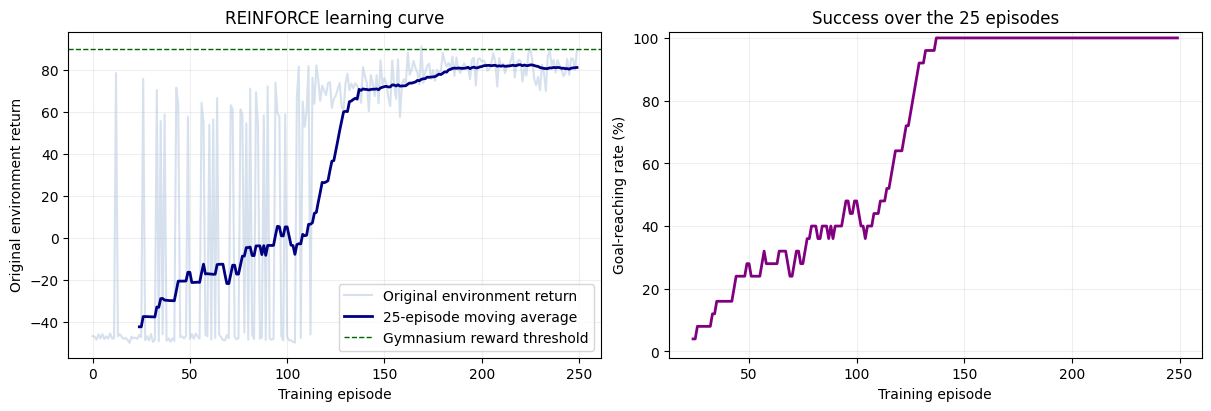

In [15]:
def moving_average(values, window):
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return np.array([], dtype=float)
    return np.convolve(
        values, np.ones(window, dtype=float) / window, mode="valid"
    )


window = 25
return_smooth = moving_average(reinforce_returns, window)
success_smooth = moving_average(
    reinforce_history["successes"].astype(float), window # how many out of window were true
)
x_smooth = np.arange(window - 1, len(reinforce_returns))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(
    reinforce_returns,
    color="lightsteelblue",
    alpha=0.5,
    label="Original environment return",
)
axes[0].plot(
    x_smooth,
    return_smooth,
    color="navy",
    linewidth=2,
    label=f"{window}-episode moving average",
)
axes[0].axhline(
    90,
    color="darkgreen",
    linestyle="--",
    linewidth=1,
    label="Gymnasium reward threshold",
)
axes[0].set_xlabel("Training episode")
axes[0].set_ylabel("Original environment return")
axes[0].set_title("REINFORCE learning curve")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(x_smooth, 100 * success_smooth, color="purple", linewidth=2)
axes[1].set_xlabel("Training episode")
axes[1].set_ylabel("Goal-reaching rate (%)")
axes[1].set_ylim(-2, 102)
axes[1].set_title(f"Success over the {window} episodes")
axes[1].grid(alpha=0.2)

plt.show()

## 9. Evaluate the learned policy

Training samples forces because $\pi_\theta$ must explore. Evaluation uses the deterministic mean force

$$
A_t=\operatorname{clip}\!\left(\mu_\theta(S_t),-1,1\right)
$$

and does not update the network. Evaluation reports only the **original Gymnasium reward**, success condition, and episode length; the shaping term is not added. Different evaluation seeds generate different starting positions, so scores should be similar but need not be identical.

In [16]:
def evaluate_mountaincar(policy, num_episodes=30, seed=2026):
    '''Evaluate the deterministic mean policy without learning or shaping.'''
    env = gym.make("MountainCarContinuous-v0")
    returns = np.zeros(num_episodes, dtype=np.float32)
    lengths = np.zeros(num_episodes, dtype=np.int32)
    successes = np.zeros(num_episodes, dtype=bool)
    policy.eval()

    for episode_index in range(num_episodes):
        episode_seed = seed if episode_index == 0 else None
        state, info = env.reset(seed=episode_seed)

        for step in range(999):
            state_tensor = torch.as_tensor(
                state, dtype=torch.float32, device=DEVICE
            )
            with torch.no_grad():
                mean, std = policy(state_tensor)
                action = mean.clamp(-1.0, 1.0)

            state, reward, terminated, truncated, info = env.step(
                action.cpu().numpy()
            )
            returns[episode_index] += reward

            if terminated or truncated:
                lengths[episode_index] = step + 1
                successes[episode_index] = terminated
                break

    env.close()
    policy.train()
    return {
        "returns": returns,
        "lengths": lengths,
        "successes": successes,
    }


reinforce_eval = evaluate_mountaincar(reinforce_policy)

print("Evaluation episodes :", len(reinforce_eval["returns"]))
print("Success rate        :",
      f"{100 * reinforce_eval['successes'].mean():.1f}%")
print("Mean env return     :", reinforce_eval["returns"].mean().round(1))
print("Mean episode length :", reinforce_eval["lengths"].mean().round(1))
print("Minimum / maximum   :",
      reinforce_eval["returns"].min().round(1), "/",
      reinforce_eval["returns"].max().round(1))

Evaluation episodes : 30
Success rate        : 100.0%
Mean env return     : 94.4
Mean episode length : 314.3
Minimum / maximum   : 90.7 / 96.4


### REINFORCE checkpoint

1. Why must the episode finish before the update?  
   Because every $\widetilde G_t$ depends on future learning rewards through the end of the episode.

2. Why is `log_prob` stored rather than only the force?  
   Its computation graph is needed for $\nabla_\theta\log\pi_\theta(\tilde A_t\mid S_t)$.

3. Why is the Gaussian sampled during training?  
   REINFORCE is on-policy and requires trajectories from its current stochastic policy.

4. What do the mean and standard deviation control?  
   The mean gives the preferred force; the standard deviation controls exploration.

5. Why retain `environment_rewards` separately?  
   Training uses an explicit momentum-shaping term, but genuine task performance must be reported with the unmodified environment reward and goal condition.

6. What makes the estimate noisy?  
   Different complete trajectories can give very different sampled returns.

# Part III - From REINFORCE to actor-critic

## 10. A value baseline and the advantage

REINFORCE can subtract any state-dependent baseline that does not depend on the sampled action:

$$
\theta
\leftarrow
\theta+
\alpha\gamma^t
\left[G_t-b(S_t)\right]
\nabla_\theta\log\pi_\theta(A_t\mid S_t).
$$

A common learned baseline is

$$
b(S_t)=\hat V_w(S_t).
$$

Because $G_t\approx q^\pi(S_t,A_t)$,

$$
G_t-\hat V_w(S_t)
\approx
q^\pi(S_t,A_t)-V^\pi(S_t)
=A^\pi(S_t,A_t).
$$

Interpretation:

- advantage $>0$: the action performed better than normally expected in this state;
- advantage $<0$: the action performed worse than normally expected;
- advantage $\approx0$: the action was close to expectation.

## 11. Replace Monte Carlo advantage with TD advantage

The Monte Carlo estimate

$$
\hat A_t^{MC}=G_t-\hat V_w(S_t)
$$

still waits for later rewards. Actor-critic methods construct a one-step TD target:

$$
y_t
=
R_{t+1}+\gamma\hat V_w(S_{t+1})
$$

for a nonterminal next state. The TD error is

$$
\delta_t
=
R_{t+1}
+\gamma\hat V_w(S_{t+1})
-\hat V_w(S_t).
$$

Its conditional expectation estimates advantage:

$$
\mathbb E[\delta_t\mid S_t=s,A_t=a]\approx A^\pi(s,a).
$$

The same signal trains both parts:

$$
\begin{aligned}
w &\leftarrow w+\alpha_c\delta_t\nabla_w\hat V_w(S_t),\\
\theta &\leftarrow\theta+\alpha_a\gamma^t\delta_t
\nabla_\theta\log\pi_\theta(A_t\mid S_t).
\end{aligned}
$$

The **actor** selects actions; the **critic** estimates state values. They are two learned components of one agent.

### One-step actor-critic algorithm

For each transition:

1. sample $A_t\sim\pi_\theta(\cdot\mid S_t)$;
2. observe $R_{t+1}$ and $S_{t+1}$;
3. compute $\delta_t=R_{t+1}+\gamma\hat V_w(S_{t+1})-\hat V_w(S_t)$;
4. update the critic toward the TD target;
5. update the actor using $\delta_t$ as the advantage estimate.

Unlike REINFORCE, this algorithm can update before the episode finishes. Bootstrapping usually reduces variance but introduces bias when $\hat V_w$ is inaccurate.

# Part IV - A2C: synchronous advantage actor-critic

## 12. From one worker to parallel workers

A2C uses several environment instances that share the same current actor and critic.

Each worker collects an $n$-step rollout:

$$
(S_t,A_t,R_{t+1},\ldots,S_{t+n}).
$$

For a rollout that does not cross a terminal state, its bootstrapped return is

$$
G_t^{(n)}
=
\sum_{k=0}^{n-1}\gamma^kR_{t+k+1}
+\gamma^n\hat V_w(S_{t+n}).
$$

The advantage estimate is

$$
\hat A_t=G_t^{(n)}-\hat V_w(S_t).
$$

All workers finish their short rollouts, their samples are combined into one batch, and then one shared update is made. This **wait-for-all barrier** is what makes A2C synchronous.

In [17]:
class ActorNetwork(nn.Module):
    '''Gaussian actor pi_theta(a|s).'''

    def __init__(self, observation_dim=2, hidden_dim=64):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(observation_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )
        self.mean_head = nn.Linear(hidden_dim, 1)
        self.log_std = nn.Parameter(torch.tensor([-0.1]))

    def forward(self, states):
        features = self.body(normalise_mountaincar_states(states))
        mean = torch.tanh(self.mean_head(features))
        std = torch.exp(self.log_std.clamp(-2.0, 0.5))
        return mean, std.expand_as(mean)


class CriticNetwork(nn.Module):
    '''Critic V_w(s).'''

    def __init__(self, observation_dim=2, hidden_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(observation_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, states):
        normalised_states = normalise_mountaincar_states(states)
        return self.network(normalised_states).squeeze(-1)


actor_demo = ActorNetwork()
critic_demo = CriticNetwork()
batch_demo = torch.tensor([
    [-0.5, 0.0],
    [-0.8, -0.02],
    [0.1, 0.04],
])
mean_demo, std_demo = actor_demo(batch_demo)

print("Actor mean shape   :", mean_demo.shape, "= [batch, action_dim]")
print("Actor std shape    :", std_demo.shape, "= [batch, action_dim]")
print("Critic output shape:", critic_demo(batch_demo).shape, "= [batch]")

Actor mean shape   : torch.Size([3, 1]) = [batch, action_dim]
Actor std shape    : torch.Size([3, 1]) = [batch, action_dim]
Critic output shape: torch.Size([3]) = [batch]


## 13. Terminal and truncated transitions

For a truly terminal transition—Mountain Car reaches the goal—

$$
G_t=\widetilde R_{t+1},
$$

because no future state value exists.

For a time-limit truncation, the underlying state is not terminal, so the final observation can still be bootstrapped:

$$
G_t=\widetilde R_{t+1}+\gamma\hat V_w(S_{t+1}^{\text{final}}).
$$

`SyncVectorEnv` automatically resets a completed worker. The helper below preserves its `final_obs` before using the reset observation for the next episode. The same final observation supplies the velocity used in the shaped learning reward.

In [18]:
def replace_reset_with_final_observations(next_states, infos):
    '''
    For SAME_STEP autoreset, recover each completed episode's final state.
    Ongoing workers already have the correct next state.
    '''
    bootstrap_states = np.asarray(next_states, dtype=np.float32).copy()
    final_mask = infos.get(
        "_final_obs",
        np.zeros(len(bootstrap_states), dtype=bool),
    )
    final_observations = infos.get("final_obs")

    if final_observations is not None:
        for worker in np.flatnonzero(final_mask):
            bootstrap_states[worker] = np.asarray(
                final_observations[worker], dtype=np.float32
            )

    return bootstrap_states

## 14. Train A2C

For a batch of $M=n\times N$ samples:

$$
\mathbb L_{\text{actor}}
=
-\frac{1}{M}\sum_{i=1}^M
\log\pi_\theta(A_i\mid S_i)\,\hat A_i
-\beta\mathbb H(\pi_\theta),
$$

$$
\mathbb L_{\text{critic}}
=
\frac{1}{2M}\sum_{i=1}^M
\left(G_i^{(n)}-\hat V_w(S_i)\right)^2.
$$

The small entropy term $\mathbb H$ discourages the policy from becoming deterministic too early. It is an implementation aid; the actor-critic mechanism is the advantage-weighted log-probability term.

In [19]:
@dataclass
class A2CConfig:
    num_envs: int = 8       # independent environment instances
    rollout_steps: int = 20
    num_updates: int = 1000
    gamma: float = 0.99
    actor_learning_rate: float = 3e-4
    critic_learning_rate: float = 6e-4
    entropy_coefficient: float = 1e-3
    momentum_reward_scale: float = MOMENTUM_REWARD_SCALE
    max_grad_norm: float = 0.5
    seed: int = SEED


def make_mountaincar_env():
    return gym.make("MountainCarContinuous-v0")


def train_a2c(config=A2CConfig()):
    '''Synchronous n-step advantage actor-critic on continuous Mountain Car.'''
    set_global_seed(config.seed)

    vector_env = gym.vector.SyncVectorEnv(
        [make_mountaincar_env for _ in range(config.num_envs)],
        autoreset_mode=gym.vector.AutoresetMode.SAME_STEP,        # SAME_STEP resets only finished epiodes in workers
    )
    first_seeds = [
        config.seed + worker for worker in range(config.num_envs)
    ]
    states, infos = vector_env.reset(seed=first_seeds)

    actor = ActorNetwork().to(DEVICE)
    critic = CriticNetwork().to(DEVICE)
    actor_optimizer = torch.optim.Adam(
        actor.parameters(), lr=config.actor_learning_rate
    )
    critic_optimizer = torch.optim.Adam(
        critic.parameters(), lr=config.critic_learning_rate
    )

    running_returns = np.zeros(config.num_envs, dtype=np.float32)
    running_lengths = np.zeros(config.num_envs, dtype=np.int32)
    completed_returns = []
    completed_lengths = []
    completed_successes = []
    actor_losses = []
    critic_losses = []

    for update_index in range(config.num_updates):
        rollout_states = []
        rollout_raw_actions = []
        rollout_rewards = []
        rollout_terminated = []
        rollout_truncated = []
        rollout_next_values = []

        # Synchronous collection: every worker contributes rollout_steps samples.
        for _ in range(config.rollout_steps):
            states_t = torch.as_tensor(                         # states for all workers
                states, dtype=torch.float32, device=DEVICE
            )
            mean_t, std_t = actor(states_t)
            distribution = Normal(mean_t, std_t)
            raw_actions_t = distribution.sample()
            actions_t = raw_actions_t.clamp(-1.0, 1.0)

            (
                next_states,
                environment_rewards,
                terminated,
                truncated,
                infos,
            ) = vector_env.step(actions_t.detach().cpu().numpy())

            bootstrap_states = replace_reset_with_final_observations(
                next_states, infos
            )
            training_rewards = (
                environment_rewards
                + config.momentum_reward_scale
                * np.abs(bootstrap_states[:, 1])       # for ongoing episodes same as next_state, for finsihed ones, it is final state of current episode
            )
            with torch.no_grad():
                next_values_t = critic(
                    torch.as_tensor(
                        bootstrap_states,
                        dtype=torch.float32,
                        device=DEVICE,
                    )
                )

            rollout_states.append(states_t)
            rollout_raw_actions.append(raw_actions_t)
            rollout_rewards.append(
                torch.as_tensor(
                    training_rewards,
                    dtype=torch.float32,
                    device=DEVICE,
                )
            )
            rollout_terminated.append(
                torch.as_tensor(
                    terminated, dtype=torch.bool, device=DEVICE
                )
            )
            rollout_truncated.append(
                torch.as_tensor(
                    truncated, dtype=torch.bool, device=DEVICE
                )
            )
            rollout_next_values.append(next_values_t)    # Values given by critic

            running_returns += environment_rewards
            running_lengths += 1
            done = terminated | truncated
            for worker in np.flatnonzero(done):
                completed_returns.append(float(running_returns[worker]))
                completed_lengths.append(int(running_lengths[worker]))
                completed_successes.append(bool(terminated[worker]))
                running_returns[worker] = 0.0
                running_lengths[worker] = 0

            states = next_states

        # Bootstrap ongoing rollouts from S_(t+n).
        with torch.no_grad():       # after 20 steps
            return_t = critic(
                torch.as_tensor(
                    states, dtype=torch.float32, device=DEVICE       # for those workers whose episodes are not finished, critic estimate, for finished, value of next state of new episode
                )
            ) # update without waiting fro complete episodes
            n_step_returns_reversed = []

            for t in range(config.rollout_steps - 1, -1, -1):
                # Truncation bootstraps from that episode's final observation.
                continuation = torch.where(
                    rollout_truncated[t],
                    rollout_next_values[t], # if truncates
                    return_t, # ordinary transition
                )
                # Genuine goal termination has zero future value.
                continuation = torch.where(
                    rollout_terminated[t],
                    torch.zeros_like(continuation), # V = 0
                    continuation,
                )
                return_t = (
                    rollout_rewards[t] + config.gamma * continuation
                )
                n_step_returns_reversed.append(return_t)

            n_step_returns = torch.stack(
                list(reversed(n_step_returns_reversed))
            ).reshape(-1)

        state_batch = torch.stack(rollout_states).reshape(-1, 2) # falttens from (20,8,2) ---> (160,2)
        raw_action_batch = torch.stack(
            rollout_raw_actions
        ).reshape(-1, 1)

        values = critic(state_batch) # crtitic prediction
        advantages = n_step_returns - values # advantage

        mean_batch, std_batch = actor(state_batch)
        distribution = Normal(mean_batch, std_batch)
        log_probabilities = distribution.log_prob(
            raw_action_batch
        ).sum(dim=-1)
        entropies = distribution.entropy().sum(dim=-1)

        actor_loss = -(
            log_probabilities * advantages.detach() # performs policy-gradient ascent on expected return
        ).mean()
        actor_loss -= config.entropy_coefficient * entropies.mean() # encourages higher entropy and therefore exploration.
        critic_loss = 0.5 * advantages.pow(2).mean() # critic prediction towrds n-step return, n=20

        actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            actor.parameters(), config.max_grad_norm
        )
        actor_optimizer.step()

        critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            critic.parameters(), config.max_grad_norm
        )
        critic_optimizer.step()

        actor_losses.append(float(actor_loss.item()))
        critic_losses.append(float(critic_loss.item()))

        if (update_index + 1) % 200 == 0:
            recent_returns = (
                np.mean(completed_returns[-50:])
                if completed_returns else float("nan")
            )
            recent_successes = sum(completed_successes[-50:])
            print(
                f"Update {update_index + 1:4d} | "
                f"completed episodes = {len(completed_returns):4d} | "
                f"mean env return = {recent_returns:6.1f} | "
                f"successes = {recent_successes:2d}/50"
            )

    vector_env.close()
    history = {
        "episode_returns": np.asarray(
            completed_returns, dtype=np.float32
        ),
        "episode_lengths": np.asarray(
            completed_lengths, dtype=np.int32
        ),
        "successes": np.asarray(completed_successes, dtype=bool),
        "actor_losses": np.asarray(actor_losses, dtype=np.float32),
        "critic_losses": np.asarray(critic_losses, dtype=np.float32),
    }
    return actor, critic, history


a2c_actor, a2c_critic, a2c_history = train_a2c()

Update  200 | completed episodes =   33 | mean env return =  -19.4 | successes =  9/50
Update  400 | completed episodes =  108 | mean env return =   75.8 | successes = 49/50
Update  600 | completed episodes =  203 | mean env return =   85.4 | successes = 50/50
Update  800 | completed episodes =  343 | mean env return =   88.7 | successes = 50/50
Update 1000 | completed episodes =  501 | mean env return =   90.1 | successes = 50/50


### A2C code-to-formula map

| Mathematics | Code |
|---|---|
| $N$ parallel workers | `SyncVectorEnv([...])` |
| $\tilde A_t^{(i)}\sim\mathbb N(\mu_\theta,\sigma_\theta^2)$ | `distribution.sample()` |
| $A_t^{(i)}=\operatorname{clip}(\tilde A_t^{(i)},-1,1)$ | `raw_actions_t.clamp(...)` |
| $\hat V_w(S_t)$ | `critic(states_t)` |
| $G_t^{(n)}$ | backward `return_t` recursion |
| $\hat A_t=G_t^{(n)}-\hat V_w(S_t)$ | `advantages = n_step_returns - values` |
| $-\log\pi_\theta(\tilde A_t\mid S_t)\hat A_t$ | main term in `actor_loss` |
| $\frac12(G_t^{(n)}-\hat V_w(S_t))^2$ | `critic_loss` |
| wait for every worker | the rollout loop finishes before either optimizer step |
| average worker information | `.mean()` over the combined batch |

In [20]:
a2c_eval = evaluate_mountaincar(a2c_actor)

print("A2C completed training episodes:", len(a2c_history["episode_returns"]))
print("A2C mean env return, last 50   :",
      a2c_history["episode_returns"][-50:].mean().round(1))
print("A2C successes, last 50         :",
      f"{a2c_history['successes'][-50:].sum()}/50")
print("A2C evaluation success rate    :",
      f"{100 * a2c_eval['successes'].mean():.1f}%")
print("A2C evaluation mean return     :",
      a2c_eval["returns"].mean().round(1))
print("A2C evaluation mean length     :",
      a2c_eval["lengths"].mean().round(1))

A2C completed training episodes: 501
A2C mean env return, last 50   : 90.1
A2C successes, last 50         : 50/50
A2C evaluation success rate    : 100.0%
A2C evaluation mean return     : 93.8
A2C evaluation mean length     : 146.9


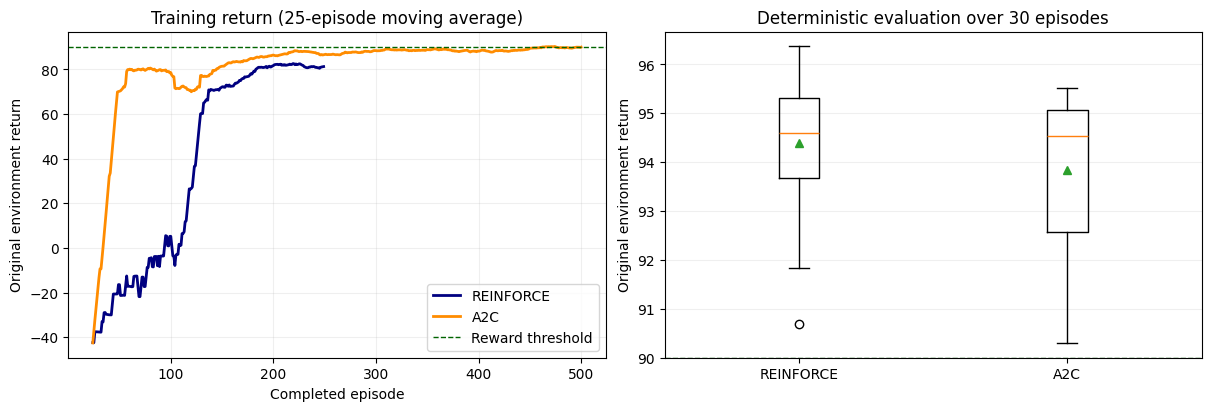

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for values, label, color in [
    (reinforce_returns, "REINFORCE", "navy"),
    (a2c_history["episode_returns"], "A2C", "darkorange"),
]:
    smooth = moving_average(values, 25)
    axes[0].plot(
        np.arange(24, len(values)),
        smooth,
        linewidth=2,
        label=label,
        color=color,
    )

axes[0].axhline(
    90,
    color="darkgreen",
    linestyle="--",
    linewidth=1,
    label="Reward threshold",
)
axes[0].set_title("Training return (25-episode moving average)")
axes[0].set_xlabel("Completed episode")
axes[0].set_ylabel("Original environment return")
axes[0].grid(alpha=0.2)
axes[0].legend()

evaluation_data = [
    reinforce_eval["returns"],
    a2c_eval["returns"],
]
axes[1].boxplot(
    evaluation_data,
    tick_labels=["REINFORCE", "A2C"],
    showmeans=True,
)
axes[1].axhline(
    90,
    color="darkgreen",
    linestyle="--",
    linewidth=1,
)
axes[1].set_title("Deterministic evaluation over 30 episodes")
axes[1].set_ylabel("Original environment return")
axes[1].grid(axis="y", alpha=0.2)

plt.show()

### Interpretation

The plots use the original environment return, not the shaped learning return. They are a demonstration, not proof that one method is universally superior:

- REINFORCE uses complete sampled returns and updates after each episode.
- A2C uses bootstrapped $n$-step returns and updates after each synchronized rollout.
- Both use the same Gaussian action model and the same explicit momentum-shaping signal during training.
- A2C collects more transitions per update because several environments run together.
- Performance depends on architecture, learning rates, rollout length, entropy coefficient, seeds, reward definition, and total environment interactions.

For a controlled research comparison, match the total number of environment steps, keep the reward definition identical, and report results over several independent training seeds.

# Part V - A3C  TO DO

## 15. A2C versus A3C

| Aspect | A2C | A3C |
|---|---|---|
| Coordination | synchronous | asynchronous |
| Update trigger | all workers finish a rollout | any worker finishes a rollout |
| Gradients | combined/averaged before update | each worker applies its own gradients |
| Waiting | waits for the slowest worker | no rollout barrier |
| Parameter version | same version during a batch | local copies may be temporarily stale |
| Typical implementation | batched/vector environments | multiprocessing with shared parameters |

Both use an actor, a critic, bootstrapped returns, and advantage-weighted policy gradients. The main difference is **when worker information updates the shared parameters**.

## 16. TO DO: complete one A3C worker

Each worker must repeatedly:

1. copy global actor and critic parameters into local networks;
2. collect a local $n$-step rollout using a worker-specific seed;
3. compute bootstrapped returns and advantages;
4. calculate local actor and critic gradients;
5. apply those gradients to the shared parameters immediately;
6. resynchronize its local networks;
7. report completed episode returns.

The function below is a skeleton only; it is intentionally not called. Multiprocessing launch code should be run from a `.py` file guarded by

```python
if __name__ == "__main__":
```

because notebook process spawning differs across operating systems.

In [22]:
def a3c_worker_todo(
    worker_id,
    global_actor,
    global_critic,
    actor_optimizer,
    critic_optimizer,
    update_lock,
    result_queue,
    config,
):
    '''STUDENT TO DO: implement one asynchronous A3C worker.'''

    worker_seed = config.seed + 1000 * worker_id
    set_global_seed(worker_seed)
    env = gym.make("MountainCarContinuous-v0")

    local_actor = ActorNetwork().to(DEVICE)
    local_critic = CriticNetwork().to(DEVICE)

    # TODO 1: copy global parameters into both local networks.
    # local_actor.load_state_dict(...)
    # local_critic.load_state_dict(...)

    state, info = env.reset(seed=worker_seed)

    for local_update in range(config.updates_per_worker):
        states = []
        raw_actions = []
        training_rewards = []

        # TODO 2: collect at most config.rollout_steps local transitions.
        # Use Normal(mean, std), sample a raw force, clip only the force sent
        # to env.step(...), and keep the original return for reporting.

        # TODO 3: bootstrap from the final state unless it is truly terminal,
        # then calculate returns backward and form advantages.

        # TODO 4: calculate local actor and critic losses and call backward().

        # TODO 5: copy local gradients to the shared models and immediately
        # call the shared optimizers. The short update_lock is a teaching-safe
        # alternative to completely lock-free Hogwild updates.

        # TODO 6: refresh local parameters from the newly updated global models.

        # TODO 7: send completed original environment returns to result_queue.

    env.close()
    result_queue.put(None)  # Signals that this worker has finished.